**TikTok Reviews Sentiment Analysis using Python**

- This is how to analyze the sentiments of the TikTok reviews. 

- TikTok is famous for its short videos. 

- People often use this app to watch entertaining and funny videos. 

- Despite its entertaining content, this application is not liked by everyone.

In [4]:
#loading libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import spacy

In [5]:
data=pd.read_csv(r"D:\IIT_MADRAS\NLP\TIKTOK SENTIMENT ANALYSIS\tiktok_google_play_reviews.csv")
data.head()

C:\Users\Global\AppData\Local\Temp\ipykernel_11896\3035566102.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv(r"D:\IIT_MADRAS\NLP\TIKTOK SENTIMENT ANALYSIS\tiktok_google_play_reviews.csv")


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,68ccaec8-1415-4301-a85e-3004679a3a83,Cassie Moore,https://play-lh.googleusercontent.com/a/ALm5wu...,No words,5,0,27.1.3,2022-11-29 21:55:37,NaN,NaN
1,d84cbfd3-6aa3-485c-aaf9-c5dca27dc966,Kaleb Plummer,https://play-lh.googleusercontent.com/a-/ACNPE...,Great fun app so far!,5,0,NaN,2022-11-29 21:55:04,NaN,NaN
2,96618aa1-31e5-4259-8649-89b75d962f00,Rylee Maher,https://play-lh.googleusercontent.com/a/ALm5wu...,The app would get a higher rating but I litera...,1,0,27.1.3,2022-11-29 21:54:48,NaN,NaN
3,078c0bda-598b-474e-a04e-d7cb3e6f6301,Kittykatelyn Romilly,https://play-lh.googleusercontent.com/a-/ACNPE...,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,5,0,NaN,2022-11-29 21:54:35,NaN,NaN
4,8e68c5cd-b12a-4206-a8da-6bfdbff44ae3,Loveness Malenga,https://play-lh.googleusercontent.com/a-/ACNPE...,Pictures and record,5,0,NaN,2022-11-29 21:54:21,NaN,NaN


- **To analyze the dataset we just need two columns [content,score].So let’s create a new dataset with just these two columns and take a step further with TikTok reviews sentiment analysis.**

In [7]:
data=data[['content','score']]
data.head()

,content,score
0,No words,5
1,Great fun app so far!,5
2,The app would get a higher rating but I litera...,1
3,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,5
4,Pictures and record,5


In [8]:
data.shape #displaying the #obervations in the dataset

(460287, 2)

**Now let’s see whether any of these two columns contain any null values:**

In [9]:
#checking for null values in the dataset
data.isnull().sum()

content    16
score       0
dtype: int64

- **There are 16 null values in the "content" column of the dataset.Lets drop the null values and move further**

In [10]:
#Dropping the null values
data.dropna(inplace=True)
data.shape

(460271, 2)

**Visualization of the dataset**

In [11]:
data["score"].value_counts()

5    338884
1     61926
4     27664
3     18618
2     13179
Name: score, dtype: int64

In [12]:
data["score"].value_counts()
total=len(data["score"])
print(total)

460271


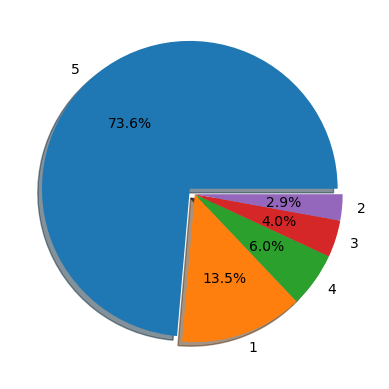

In [13]:
#Using matplotlib
ratings=data["score"].value_counts(ascending=False)
rating_num=ratings.index
quantity=ratings.values
plt.pie(ratings,labels=rating_num,autopct='%1.1f%%',shadow=True,explode = [0.05,0,0,0,0])
plt.show()

In [14]:
#Using Plotly
import plotly.express as px

ratings = data["score"].value_counts()
numbers = ratings.index
quantity = ratings.values
figure = px.pie(data,values=quantity,names=numbers,hole = 0.5)
figure.show()

**You can see that 73.6%% of the users have given five ratings to TikTok, and 13.5% of the users have rated it with 1.**

- Now let’s prepare this data for the task of sentiment analysis. Here we have to clean the text in the content column:

**Installation of spacy** 

! pip install spacy

In [41]:
#!pip install -U pip setuptools wheel
#!pip install -U spacy

  Using cached pip-23.2.1-py3-none-any.whl (2.1 MB)
     -------------------------------------- 805.2/805.2 kB 4.2 MB/s eta 0:00:00
  Using cached wheel-0.41.1-py3-none-any.whl (64 kB)


ERROR: To modify pip, please run the following command:
C:\Users\Global\anaconda3\python.exe -m pip install -U pip setuptools wheel


- Install a default trained pipeline package, get the code to load it from within spaCy

In [42]:
# ! python -m spacy download en_core_web_sm

     ---------------------------------------- 12.8/12.8 MB 3.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


**Now let’s prepare this data for the task of sentiment analysis. Here we have to clean the text in the content column:**

In [18]:
nlp = spacy.load("en_core_web_sm") 
def clean_doc(sentence):
    doc = nlp(sentence)
    return " ".join(token.lemma_ for token in doc)


In [20]:
data.head()

,content,score
0,No words,5
1,Great fun app so far!,5
2,The app would get a higher rating but I litera...,1
3,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,5
4,Pictures and record,5


- **apply() : It takes a function as an input and applies this function to an entire DataFrame.**

In [21]:
data["clean_text"] = data.content.apply(lambda x: clean_doc(x))

In [24]:
data=data[["clean_text","score"]]

In [25]:
data.head()

,clean_text,score
0,no word,5
1,great fun app so far !,5
2,the app would get a high rating but I literall...,1
3,I wish I could give this a 100 percent rating ...,5
4,picture and record,5


**Now let’s have a look at the kind of words the users use in the reviews of TikTok:**

**To install wordcloud**

In [ ]:
#! pip install wordcloud

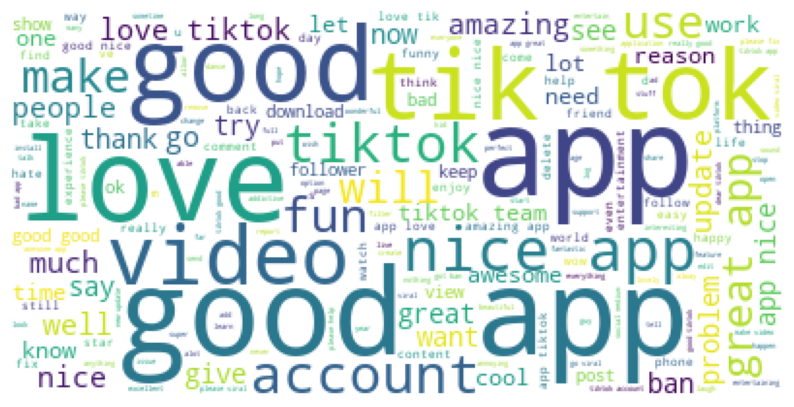

In [27]:
from wordcloud import WordCloud,STOPWORDS

text = " ".join (i for i in data.clean_text)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure( figsize=(10,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

- **Now I will add three more columns in this dataset as Positive, Negative, and Neutral by calculating the sentiment scores of the tweets:**

**USING  VADER SENTIMENT ANALYSIS TOOLS**

- **VADER: A Rule-based Model for Sentiment Analysis of Social Media Text**

In [28]:
import nltk
nltk.download("vader_lexicon") #download package vader_lexicon
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sentiments=SentimentIntensityAnalyzer()
data["Positive"]=[sentiments.polarity_scores(i)["pos"] for i in data["clean_text"]]
data["Negative"]=[sentiments.polarity_scores(i)["neg"] for i in data["clean_text"]]
data["Neutral"]=[sentiments.polarity_scores(i)["neu"] for i in data["clean_text"]]


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Global\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [30]:
data=data[["clean_text","Positive","Negative","Neutral"]]
data.head(20)

,clean_text,Positive,Negative,Neutral
0,no word,0.000,0.688,0.312
1,great fun app so far !,0.719,0.000,0.281
2,the app would get a high rating but I literall...,0.023,0.048,0.929
3,I wish I could give this a 100 percent rating ...,0.517,0.000,0.483
4,picture and record,0.000,0.000,1.000
5,I love this amazing app,0.800,0.000,0.200
6,Mohammed Rehan,0.000,0.000,1.000
7,love be on Tik Tok .,0.512,0.000,0.488
8,Kwai pelo menos da dinheiro,0.000,0.000,1.000
9,post to view be such a step backwards for the ...,0.074,0.140,0.785


- **Now let’s have a look at the kind of words people use in the positive reviews of TikTok:**

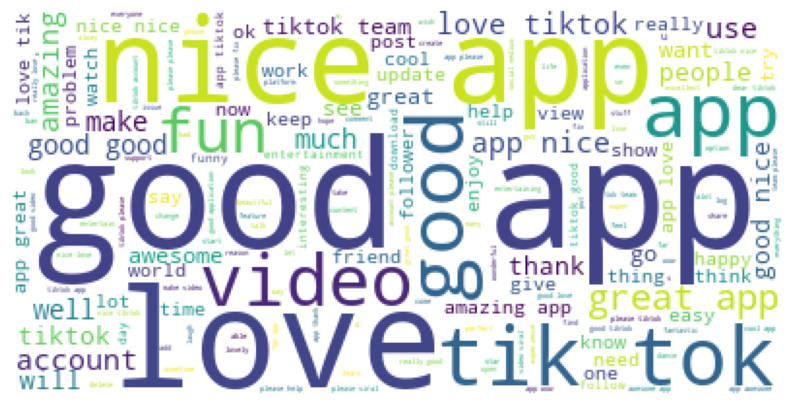

In [31]:
postive=" ".join([i for i in data["clean_text"][data["Positive"]>data["Negative"]]])
stopwords=set(STOPWORDS)
wordcloud=WordCloud(stopwords=stopwords,background_color="white").generate(postive)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

- **Now let's have a look at the kind of words people use in the Negative reviews of TikTok:**

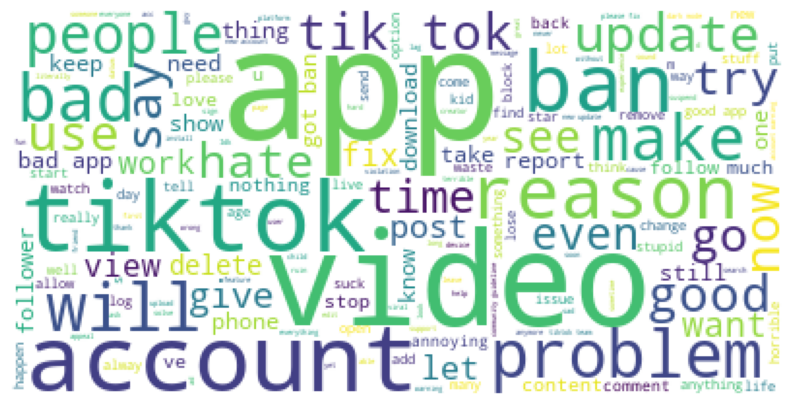

In [32]:
negative=" ".join([i for i in data["clean_text"] [data["Positive"]<data["Negative"]]])
stopwords=set(STOPWORDS)
wordcloud=WordCloud(stopwords=stopwords,background_color="white").generate(negative)
plt.figure(figsize=(10,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


**SUMMARY**

- **So this is how to analyze the sentiments of the TikTok reviews using Sentiment Ananlysis in python.**
- **TikTok is famous for its short videos. People often use this app to watch entertaining and funny videos.**
